# PENGWIN: detección y segmentación de fracturas pélvicas en CT

Proyecto Integrador Corte 2, Analítica de Datos, UAO 2026-2.

Uso exclusivamente académico. No es un dispositivo médico ni sirve para decisiones clínicas.

Contenido:

1. Estado del proyecto
2. Datos
3. Carga de los volúmenes
4. Arquitectura
5. Detección con grid y NMS
6. Función de pérdida
7. Prueba de overfit
8. Entrenamiento
9. Resultados en test
10. Ablación
11. Predicciones
12. Pendientes
13. Cómo reproducirlo

El notebook lee los resultados guardados en `reports/`, así que corre sin datos ni GPU. Si están el caché de cortes (`PENGWIN_CACHE_DIR`) y los checkpoints, vuelve a generar las figuras.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "03_src" / "pengwin").is_dir():
            return p
    raise FileNotFoundError("No se encontró la raíz del repositorio (carpeta 03_src/pengwin)")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "03_src"))
REP = ROOT / "reports"
FIG = REP / "figures" / "sustentacion"
FIG.mkdir(parents=True, exist_ok=True)
CACHE = Path(os.environ.get("PENGWIN_CACHE_DIR", ROOT / "data_processed"))
CKPT = {r: ROOT / "checkpoints" / r / "best.pth" for r in ("base", "sin_cbam", "sin_tl")}

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
HAS_CACHE = (CACHE / "024" / "meta.json").exists()
HAS_CKPT = CKPT["base"].exists()
print(f"Repositorio : {ROOT}")
print(f"torch       : {'sí' if HAS_TORCH else 'no'} | caché de cortes: {'sí' if HAS_CACHE else 'no'} ({CACHE}) "
      f"| checkpoint base: {'sí' if HAS_CKPT else 'no'}")

Repositorio : C:\Users\Ncuar\OneDrive\Desktop\Octavo Semestre\Analitica de Datos\Proyecto#2 git\Analitica-de-datos-Proyecto-2-PENGWIN
torch       : sí | caché de cortes: sí (D:\PENGWIN\data_processed) | checkpoint base: sí


In [2]:
# Estilo: el mismo del EDA. Color por ENTIDAD, fijo en todo el notebook.
C = {"SA": "#2a78d6", "LI": "#eb6834", "RI": "#1baf7a"}              # sacro, coxal izq., coxal der.
RUN = {"base": ("#2a78d6", "-", "Base (CBAM + TL)"), "sin_cbam": ("#eb6834", "--", "Sin CBAM"),
       "sin_tl": ("#1baf7a", ":", "Sin TL (desde cero)")}
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "font.size": 9, "lines.linewidth": 2,
})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")


def show_saved(path, width=900):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"(sin figura guardada: {path.relative_to(ROOT)})")


def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))

## 1. Estado del proyecto

El sistema tiene que detectar el sacro y los dos coxales en cada corte, segmentar los fragmentos, colorearlos según el hueso y medir en mm qué tan separado está cada fragmento del principal. Todo eso termina en un dashboard.

Esto es lo que llevamos al cierre de la semana 9:

In [3]:
estado = pd.DataFrame([
    # (bloque, requisito, estado, evidencia)
    ("Datos", "Pipeline de carga .mha, ventaneo HU, splits fijos por paciente", "Hecho", "§2-3 · data_loader.py, slice_cache.py, splits.json (SMD 0,155)"),
    ("Datos", "EDA de fragmentos por caso", "Hecho", "04_notebook/01_eda_pengwin.ipynb"),
    ("Modelo", "Backbone propio que extiende FundidoraPC", "Hecho", "§4 · models/backbone.py"),
    ("Modelo", "CBAM antes de la bifurcación", "Hecho", "§4 · models/cbam.py (bloques 3 y 4)"),
    ("Modelo", "Tres cabezas sobre un backbone", "Hecho", "§4 · models/heads.py"),
    ("Modelo", "Transfer learning solo en el backbone", "Hecho", "§4 · FundidoraPC del Taller 3"),
    ("Detección", "Cajas por región con grid propio", "Hecho", "§5 · detection/grid.py (stride 8)"),
    ("Detección", "NMS propia", "Hecho", "§5 · detection/nms.py + tests de control"),
    ("Pérdida", "Pérdida compuesta con λ calibrados y justificados", "Hecho", "§6 · reports/lambdas.json"),
    ("Correctitud", "Overfit intencional en un batch pequeño", "Hecho", "§7 · reports/overfit/"),
    ("Cómputo", "AMP, 224-256 px, batch 8-16", "Hecho", "256 px, batch 8, torch.amp"),
    ("Métricas", "F1/AUC, IoU/mAP, Dice/IoU por región", "Hecho", "§9 · reports/eval/*_test.json"),
    ("Ablación", "Con/sin CBAM y con/sin transfer learning", "Hecho", "§10"),
    ("Segmentación", "Instancia por fragmento (dos etapas: región → fragmentos)", "Parcial", "Semántica + borde de fractura listos; falta separar instancias en 3D (semana 10)"),
    ("Métricas", "Dice/IoU por fragmento, HD95/ASSD (opcionales)", "Pendiente", "Semana 10"),
    ("Medición", "Distancia de separación en mm (EDT + spacing)", "Parcial", "Convención fijada y probada (tests); falta sobre predicción vs GT"),
    ("Baseline", "SAM zero-shot con la caja predicha como prompt", "Pendiente", "Semana 10"),
    ("Cómputo", "Latencia por imagen en GPU y CPU", "Parcial", "GPU medida (§9); falta CPU"),
    ("Dashboard", "Visualizador 1: MIP del volumen crudo", "Hecho", "visualization/mip_viewer.py"),
    ("Dashboard", "Visualizador 2: inferencia corte a corte con slider", "Parcial", "Overlay listo (visualization/overlay.py); falta app Streamlit"),
    ("Dashboard", "Visualizador 3: reconstrucción 3D con distancias", "Pendiente", "Semana 11"),
    ("Entrega", "Túnel Cloudflare, model card, pitch, video de respaldo", "Pendiente", "Semana 11"),
    ("Entrega", "IA_USAGE.md, README reproducible, semillas", "Hecho", "IA_USAGE.md, README.md"),
], columns=["Bloque", "Requisito", "Estado", "Evidencia"])

resumen = estado.Estado.value_counts().reindex(["Hecho", "Parcial", "Pendiente"]).fillna(0).astype(int)
display(Markdown(" · ".join(f"**{k}:** {v}" for k, v in resumen.items())))
estado.style.apply(lambda s: [f"color: {INK}; font-weight: bold" if v == "Pendiente" else "" for v in s], subset=["Estado"]).hide(axis="index")

**Hecho:** 15 · **Parcial:** 4 · **Pendiente:** 4

Bloque,Requisito,Estado,Evidencia
Datos,"Pipeline de carga .mha, ventaneo HU, splits fijos por paciente",Hecho,"§2-3 · data_loader.py, slice_cache.py, splits.json (SMD 0,155)"
Datos,EDA de fragmentos por caso,Hecho,04_notebook/01_eda_pengwin.ipynb
Modelo,Backbone propio que extiende FundidoraPC,Hecho,§4 · models/backbone.py
Modelo,CBAM antes de la bifurcación,Hecho,§4 · models/cbam.py (bloques 3 y 4)
Modelo,Tres cabezas sobre un backbone,Hecho,§4 · models/heads.py
Modelo,Transfer learning solo en el backbone,Hecho,§4 · FundidoraPC del Taller 3
Detección,Cajas por región con grid propio,Hecho,§5 · detection/grid.py (stride 8)
Detección,NMS propia,Hecho,§5 · detection/nms.py + tests de control
Pérdida,Pérdida compuesta con λ calibrados y justificados,Hecho,§6 · reports/lambdas.json
Correctitud,Overfit intencional en un batch pequeño,Hecho,§7 · reports/overfit/


## 2. Datos

Tenemos 100 tomografías de PENGWIN en formato `.mha`, cada una con su máscara. En la máscara, cada número es un fragmento:

| Etiquetas | Hueso | Principal | Fragmentos |
|---|---|---|---|
| 1-10 | Sacro | 1 | 2-10 |
| 11-20 | Coxal izquierdo | 11 | 12-20 |
| 21-30 | Coxal derecho | 21 | 22-30 |

El EDA completo está en `01_eda_pengwin.ipynb`.

In [4]:
cases = pd.read_csv(REP / "eda" / "eda_cases.csv", dtype={"case_id": str})
frags = pd.read_csv(REP / "eda" / "eda_fragments.csv", dtype={"case_id": str})
sp = read_json(ROOT / "01_data" / "splits.json")
sec = frags[~frags.is_main]
datos = pd.DataFrame([
    ("Casos", f"{len(cases)}"),
    ("Orientación en disco LPS / RAS", " / ".join(str((cases.orientation_orig == k).sum()) for k in ("LPS", "RAS"))),
    ("Cortes por volumen (mediana, rango)", f"{int(cases.dim_z.median())} ({cases.dim_z.min()}-{cases.dim_z.max()})"),
    ("Espesor de corte dz (mm)", f"{cases.dz.min():.3f} - {cases.dz.max():.3f}"),
    ("Píxel en el plano (mm)", f"{cases.dx.min():.2f} - {cases.dx.max():.2f}"),
    ("Fragmentos totales / secundarios", f"{len(frags)} / {len(sec)}"),
    ("Secundarios en contacto con el principal", f"{100 * sec.contact_with_main.mean():.1f} %"),
    ("Partición train / val / test (por paciente)", f"{sp['counts']['train']} / {sp['counts']['val']} / {sp['counts']['test']} · SMD máx {sp['smd_max']}"),
], columns=["Dato", "Valor"])
datos.style.hide(axis="index")

Dato,Valor
Casos,100
Orientación en disco LPS / RAS,66 / 34
"Cortes por volumen (mediana, rango)",326 (193-414)
Espesor de corte dz (mm),0.625 - 1.250
Píxel en el plano (mm),0.66 - 1.22
Fragmentos totales / secundarios,575 / 275
Secundarios en contacto con el principal,88.7 %
Partición train / val / test (por paciente),70 / 15 / 15 · SMD máx 0.1548


Lo que tomamos del EDA para el modelo:

- 34 casos vienen volteados (RAS), así que todo se pasa a LPS.
- Recortamos alrededor del hueso y no del cuerpo, para tener más resolución.
- Usamos la ventana ósea L400/W1800.
- Las cajas del sacro son pequeñas, por eso la detección trabaja en celdas de 8 px.
- Casi todos los fragmentos tocan al principal, así que entrenamos un mapa de bordes para poder separarlos.
- La partición train/val/test se hizo por paciente y quedó balanceada.

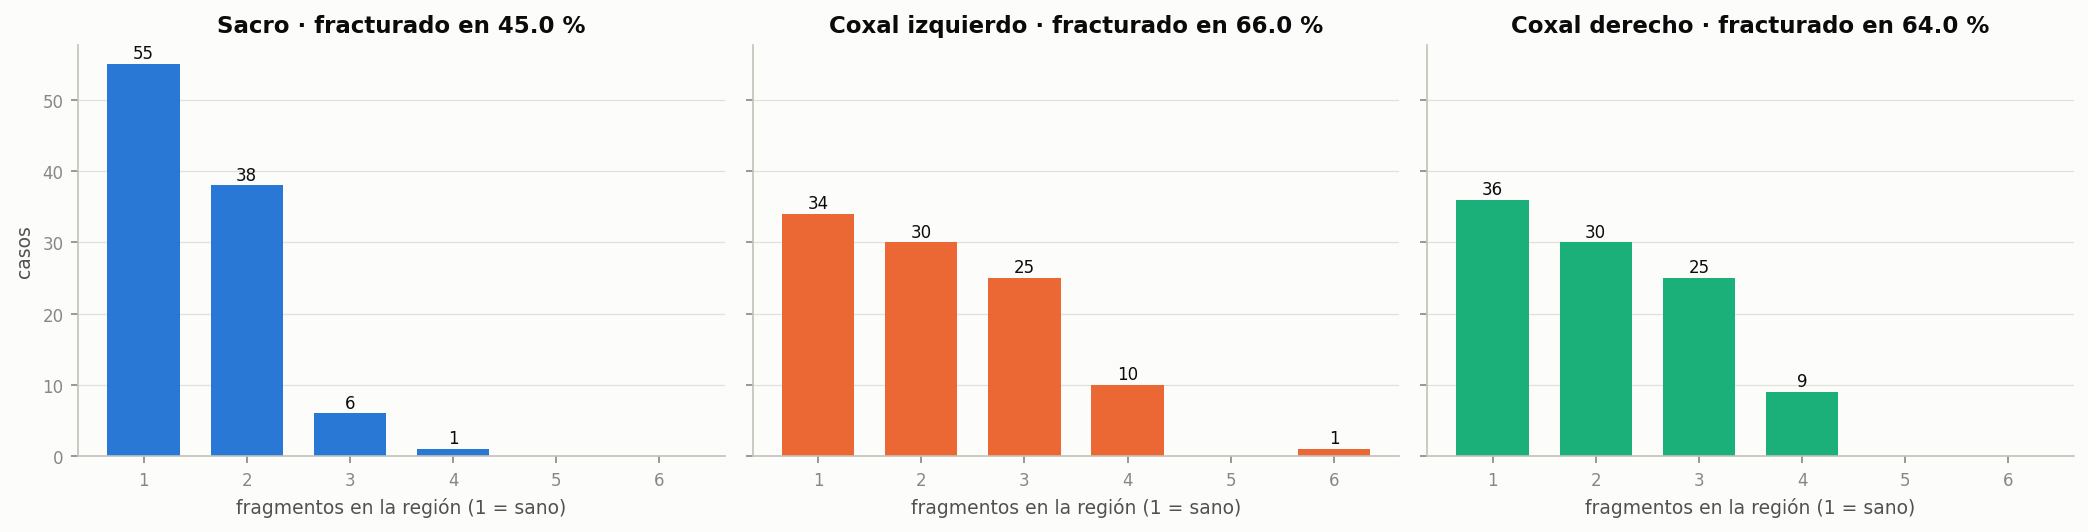

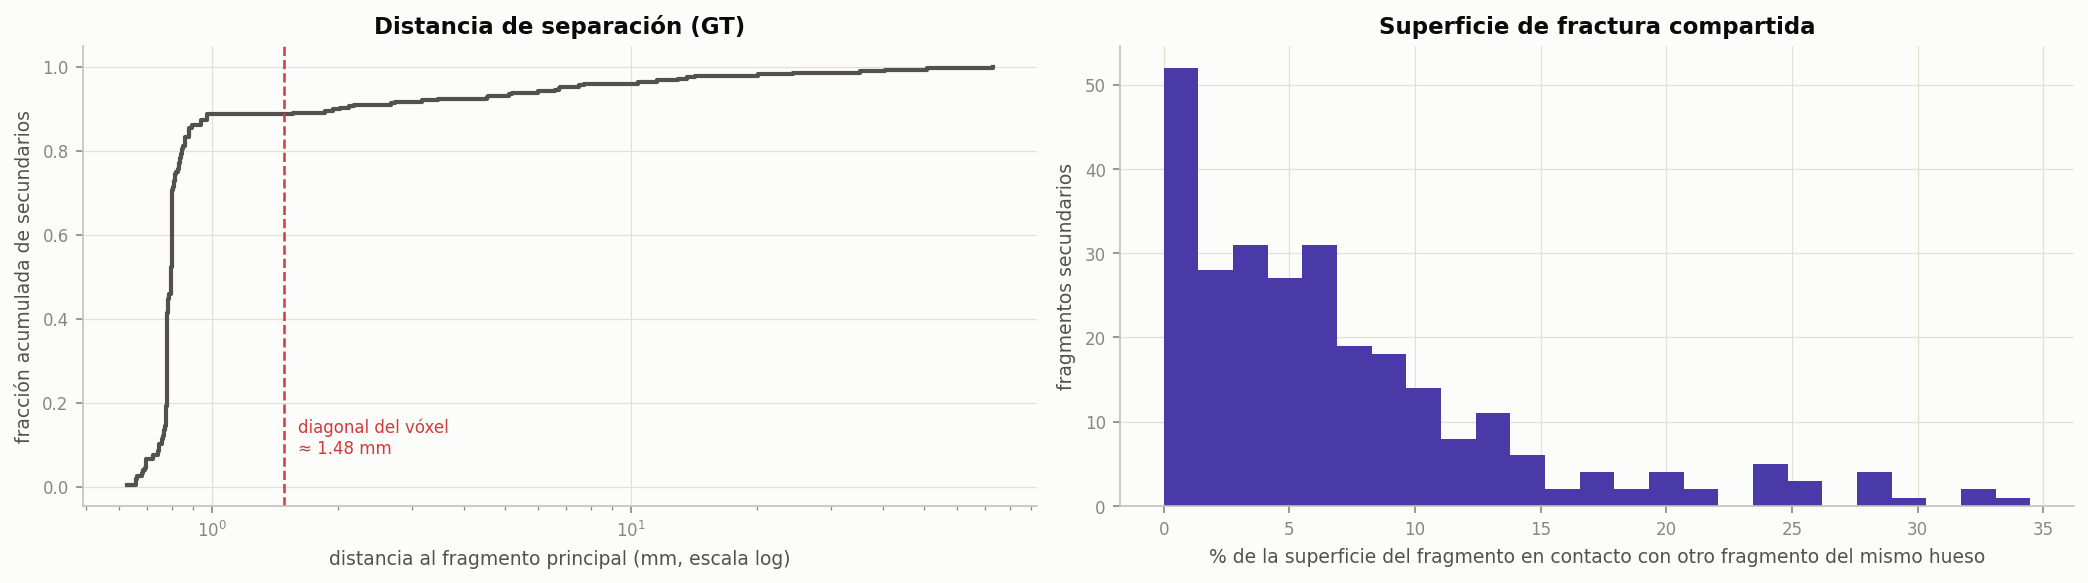

In [5]:
show_saved(REP / "figures" / "eda" / "05_fragmentos_region.png", 820)
show_saved(REP / "figures" / "eda" / "07_separacion.png", 820)

## 3. Carga de los volúmenes

Cada `.mha` se procesa así:

1. Se lee con SimpleITK y se reorienta a LPS.
2. Se recorta un cuadrado alrededor del esqueleto.
3. Se aplica la ventana ósea.
4. Cada corte se lleva a 256 x 256 (la máscara con vecino más cercano, para no inventar etiquetas).
5. Se guarda en un caché por caso, junto con el spacing y el recorte, para poder volver a milímetros.

A la red le entra un corte junto con el de arriba y el de abajo (separados unos 2 mm), como si fueran los 3 canales de una imagen.

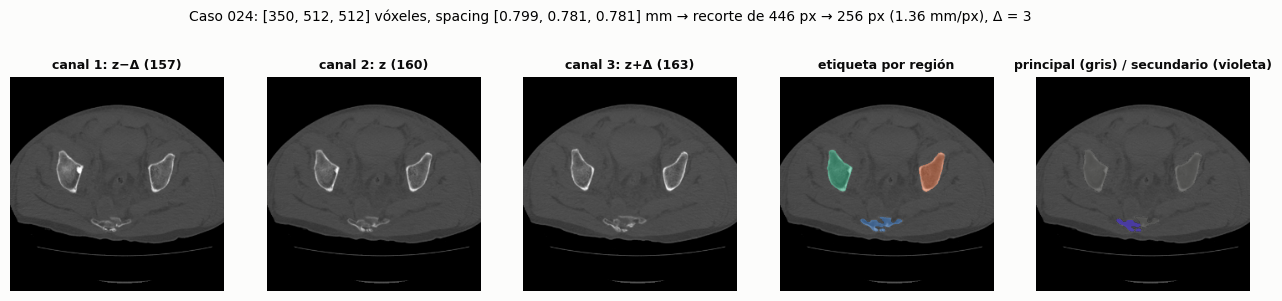

In [6]:
pipe_png = FIG / "03_pipeline_carga.png"
if HAS_CACHE and HAS_TORCH:
    from pengwin.data.dataset import context_stack
    from pengwin.data.slice_cache import load_case_cache
    from pengwin.data.targets import region_of
    from pengwin.visualization.overlay import colorize

    case = "024"
    image, label, meta = load_case_cache(CACHE / case)
    z = meta["bone_slices"][len(meta["bone_slices"]) // 2]
    d = meta["context_offset"]
    stack = context_stack(image, z, d)
    fig, ax = plt.subplots(1, 5, figsize=(16, 3.6))
    for k, t in enumerate((f"canal 1: z−Δ ({z - d})", f"canal 2: z ({z})", f"canal 3: z+Δ ({z + d})")):
        ax[k].imshow(stack[k], cmap="gray")
        ax[k].set_title(t, fontsize=9)
    ax[3].imshow(stack[1], cmap="gray")
    ax[3].imshow(colorize(region_of(np.asarray(label[z]))))
    ax[3].set_title("etiqueta por región", fontsize=9)
    lab_z = np.asarray(label[z])
    frag = np.zeros(lab_z.shape + (4,), np.float32)
    frag[(lab_z > 0) & ((lab_z - 1) % 10 == 0)] = (0.32, 0.32, 0.31, 0.75)        # principal: gris
    frag[(lab_z > 0) & ((lab_z - 1) % 10 > 0)] = (0.29, 0.23, 0.65, 0.95)         # secundario: violeta
    ax[4].imshow(stack[1], cmap="gray")
    ax[4].imshow(frag)
    ax[4].set_title("principal (gris) / secundario (violeta)", fontsize=9)
    for a in ax:
        a.axis("off")
    fig.suptitle(f"Caso {case}: {meta['native_shape_zyx']} vóxeles, spacing {np.round(meta['spacing_zyx'], 3).tolist()} mm "
                 f"→ recorte de {meta['crop']['side_px']} px → 256 px ({meta['pixel_mm']:.2f} mm/px), Δ = {d}", fontsize=10)
    savefig(fig, "03_pipeline_carga")
    plt.show()
else:
    show_saved(pipe_png)

## 4. Arquitectura

Es una sola red: un backbone compartido y tres cabezas.

```
corte (3 x 256 x 256)
  backbone: FundidoraPC + residual en cada bloque + CBAM en los bloques 3 y 4
     C1 (128x128)  C2 (64x64)  C3 (32x32)  C4 (16x16)
  cabeza 1, clasificación: ¿qué huesos hay en el corte?
  cabeza 2, detección:     una caja por hueso (grid 32x32 + NMS)
  cabeza 3, segmentación:  máscara por hueso + bordes de fractura
```

- El backbone parte de los 4 bloques de la FundidoraPC del curso, con los pesos del Taller 3.
- A cada bloque le agregamos un bloque residual.
- CBAM está en los dos bloques más profundos, antes de que se separen las cabezas.
- Las cabezas se entrenan desde cero.

In [7]:
if HAS_TORCH:
    from pengwin.models.pengwin_net import PengwinNet, count_parameters
    from pengwin.utils.config import load_config

    cfg = load_config(ROOT / "configs" / "base.yaml")
    net = PengwinNet(cfg["model"]).eval()
    with torch.no_grad():
        out = net(torch.zeros(1, 3, 256, 256))
    params = count_parameters(net)
    tabla = pd.DataFrame({"parámetros": params}).assign(**{"%": lambda t: 100 * t["parámetros"] / params["total"]})
    display(tabla.style.format({"parámetros": "{:,.0f}", "%": "{:.1f}"}))
    display(pd.DataFrame({k: [tuple(v.shape)] for k, v in out.items()}, index=["forma de salida"]).T)
else:
    print("torch no está instalado: se omite el conteo de parámetros (2,92 M en total).")

,parámetros,%
backbone,"1,967,972",67.4
neck,"197,120",6.7
cls_head,771,0.0
det_head,"608,143",20.8
seg_head,"147,877",5.1
total,"2,921,883",100.0


,forma de salida
cls_logits,"(1, 3)"
det_scores,"(1, 3, 32, 32)"
det_ltrb,"(1, 3, 4, 32, 32)"
seg_logits,"(1, 4, 256, 256)"
edge_logits,"(1, 1, 256, 256)"


## 5. Detección con grid y NMS

La imagen se divide en 32 x 32 celdas de 8 px. Cada celda predice, para cada hueso, un puntaje y las distancias a los cuatro lados de la caja.

Las celdas positivas son las que están cerca del centro de la caja real (los cuadros de color en la figura). Al predecir, nos quedamos con las celdas de puntaje alto, armamos sus cajas y la NMS deja una sola caja por hueso. La NMS la programamos nosotros.

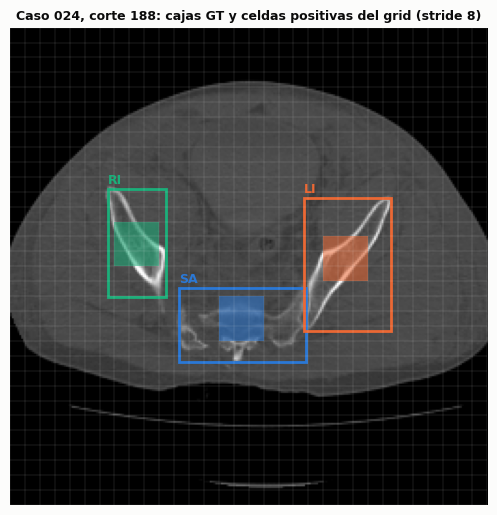

In [8]:
grid_png = FIG / "05_grid_positivos.png"
if HAS_CACHE and HAS_TORCH:
    from matplotlib.patches import Rectangle
    from pengwin.data.slice_cache import load_case_cache
    from pengwin.data.targets import slice_targets
    from pengwin.detection.grid import assign_targets

    case = "024"
    image, label, meta = load_case_cache(CACHE / case)
    z = meta["bone_slices"][int(len(meta["bone_slices"]) * 0.6)]
    t = slice_targets(np.asarray(label[z]))
    a = assign_targets(torch.from_numpy(t["boxes"])[None], torch.from_numpy(t["present"])[None],
                       torch.from_numpy(t["ignore"])[None], 32, 8)
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.imshow(np.asarray(image[z]), cmap="gray")
    for g in range(0, 257, 8):
        ax.axhline(g - 0.5, color="white", lw=0.25, alpha=0.35)
        ax.axvline(g - 0.5, color="white", lw=0.25, alpha=0.35)
    for k, name in enumerate(("SA", "LI", "RI")):
        if not t["present"][k]:
            continue
        x0, y0, x1, y1 = t["boxes"][k]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=C[name], lw=2))
        for i, j in zip(*np.nonzero(a["pos"][0, k].numpy())):
            ax.add_patch(Rectangle((j * 8 - 0.5, i * 8 - 0.5), 8, 8, color=C[name], alpha=0.55, lw=0))
        ax.text(x0, y0 - 3, name, color=C[name], fontsize=9, fontweight="bold")
    ax.set_title(f"Caso {case}, corte {z}: cajas GT y celdas positivas del grid (stride 8)", fontsize=9)
    ax.axis("off")
    savefig(fig, "05_grid_positivos")
    plt.show()
else:
    show_saved(grid_png, 520)

## 6. Función de pérdida

$$L = \lambda_{cls} L_{cls} + \lambda_{det} L_{det} + \lambda_{seg} L_{seg}$$

- Clasificación: BCE.
- Detección: focal + GIoU.
- Segmentación: entropía cruzada + Dice, y lo mismo para el borde.

Para calibrar los λ entrenamos 200 iteraciones con λ = 1 y medimos cuánto mueve cada pérdida al último bloque compartido. Al que empuja más le toca un λ menor, y al revés.

In [9]:
lam = read_json(REP / "lambdas.json")
pd.DataFrame({"G medio (‖∇L‖)": lam["G_media"], "G mediana": lam["G_mediana"], "λ calibrado": lam["lambdas"]}).T.round(4)

,cls,det,seg
G medio (‖∇L‖),0.085,0.165,0.107
G mediana,0.068,0.173,0.110
λ calibrado,1.306,0.667,1.027


La detección es la que más empuja, por eso queda con el λ más bajo.

## 7. Prueba de overfit

Antes de entrenar en serio comprobamos que la red pudiera memorizar 8 cortes. Si no lo logra, hay algo mal conectado.

Los criterios se fijaron antes de correrla: la pérdida baja al menos 95 %, Dice ≥ 0,95, mAP@0.5 ≥ 0,95 y el gradiente llega a las tres cabezas.

In [10]:
ov = read_json(REP / "overfit" / "overfit_base.json")
pd.DataFrame([{"criterio": k, "resultado": (v[0] if not isinstance(v[0], dict) else "backbone y 3 cabezas"),
               "cumple": "sí" if v[1] else "no"} for k, v in ov["checks"].items()]).style.hide(axis="index")

criterio,resultado,cumple
loss_drop,0.988032,sí
dice,0.991862,sí
map50,1.000000,sí
gradiente_en_todas_las_cabezas,backbone y 3 cabezas,sí


**Resultado: APROBADA** en el primer intento.

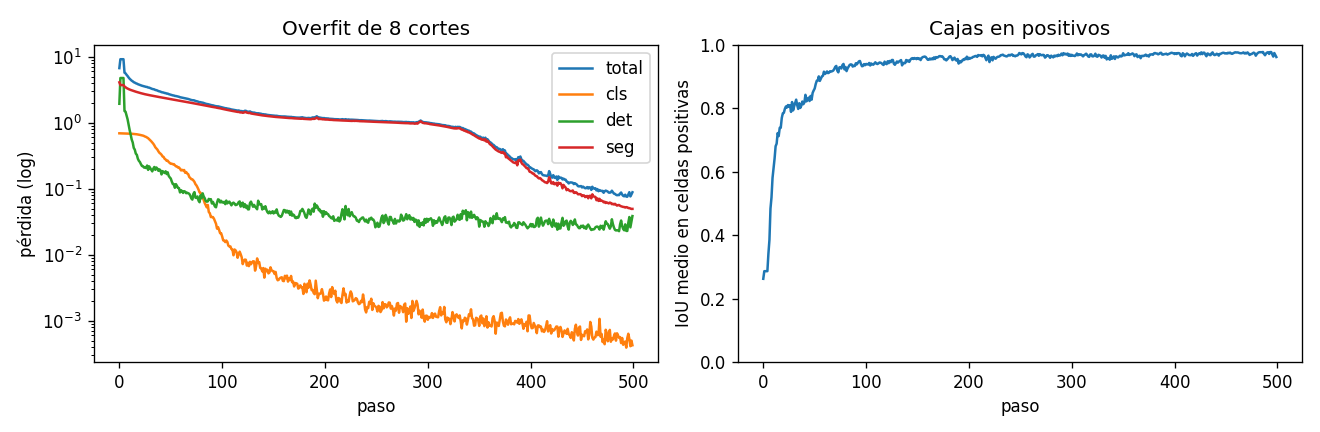

In [11]:
display(Markdown(f"**Resultado: {'APROBADA' if ov['passed'] else 'NO APROBADA'}** en el primer intento."))
show_saved(REP / "overfit" / "overfit_base.png", 820)

## 8. Entrenamiento

Entrenamos tres modelos de 40 épocas en ANTON (DGX Spark), unas 2 horas cada uno:

- base;
- sin CBAM;
- sin transfer learning.

Configuración común: batch 8, AdamW, lr 3e-4, precisión mixta y semilla 42. La aumentación usa escala, rotación, brillo y contraste, sin voltear la imagen para no cambiar izquierda por derecha.

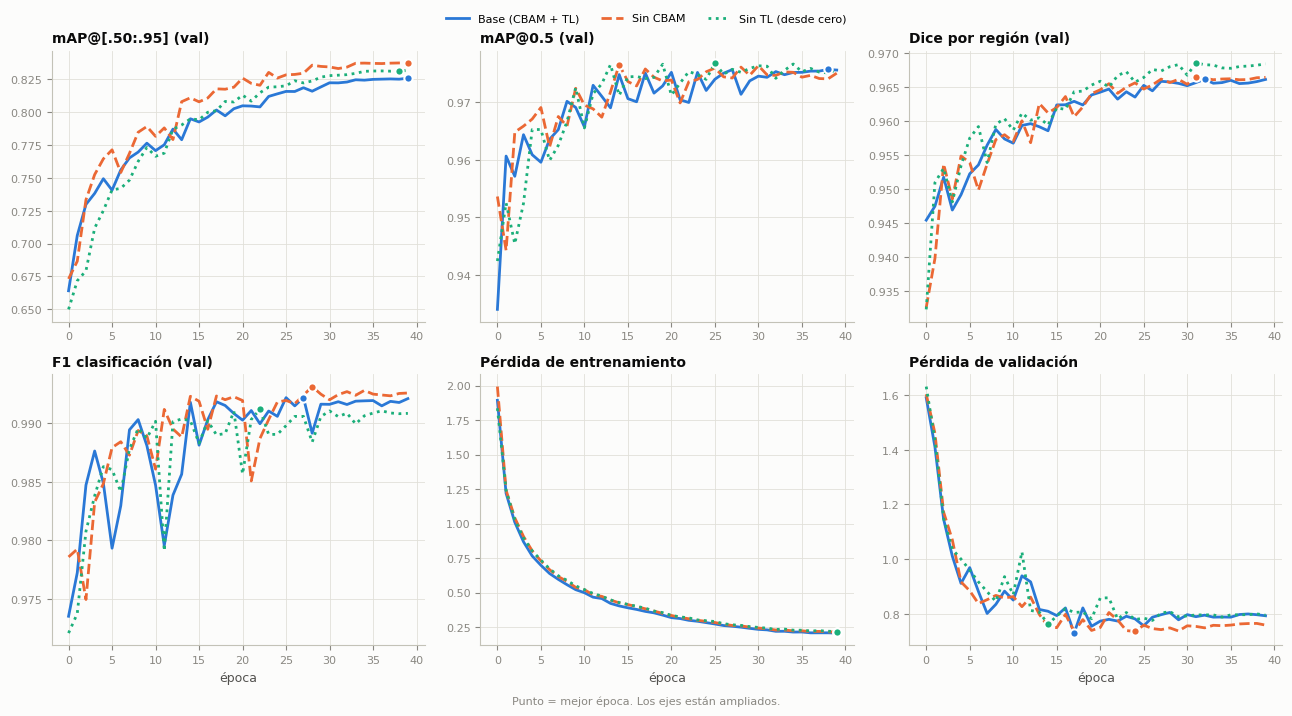

,Base (CBAM + TL),Sin CBAM,Sin TL (desde cero)
épocas,40.0,40.0,40.0
s por época (media),165.7,185.8,179.4
horas,1.8,2.1,2.0
mejor época (val),39.0,28.0,31.0


In [12]:
def load_hist(run):
    for p in (REP / "train" / f"{run}_history.csv", ROOT / "runs" / run / "history.csv"):
        if p.exists():
            return pd.read_csv(p)


H = {r: load_hist(r) for r in RUN}
H = {r: h for r, h in H.items() if h is not None}
panels = [("mAP@[.50:.95]", "mAP@[.50:.95] (val)", "max"), ("mAP@0.50", "mAP@0.5 (val)", "max"),
          ("dice_hueso", "Dice por región (val)", "max"), ("cls_f1_macro", "F1 clasificación (val)", "max"),
          ("train_total", "Pérdida de entrenamiento", "min"), ("val_total", "Pérdida de validación", "min")]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.8))
for ax, (col, title, best) in zip(axes.flat, panels):
    for r, h in H.items():
        color, ls, name = RUN[r]
        ax.plot(h.epoch, h[col], color=color, ls=ls, label=name)
        i = h[col].idxmax() if best == "max" else h[col].idxmin()
        ax.plot(h.epoch[i], h[col][i], "o", ms=6, color=color, mec="white", mew=1.5, zorder=3)
    ax.set_title(title, loc="left", fontsize=10)
for ax in axes[1]:
    ax.set_xlabel("época")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.text(0.5, -0.01, "Punto = mejor época. Los ejes están ampliados.",
         ha="center", fontsize=8, color=MUTED)
fig.tight_layout()
savefig(fig, "08_curvas_entrenamiento")
plt.show()
pd.DataFrame({RUN[r][2]: {"épocas": len(h), "s por época (media)": h.seconds.mean(), "horas": h.seconds.sum() / 3600,
                          "mejor época (val)": int(read_json(REP / "train" / f"{r}.json")["mejor"]["epoch"])}
              for r, h in H.items()}).round(1)

La pérdida de entrenamiento baja parejo en los tres. La de validación se estabiliza cerca de la época 17, aunque las métricas siguen subiendo un poco. El modelo sin transfer learning arranca más lento y alcanza a los otros hacia la época 12.

## 9. Resultados en test

Test son 15 pacientes que el modelo no vio durante el entrenamiento.

In [13]:
OBJ = {"cls_f1_macro": ("Clasificación", "F1", 0.85), "cls_auc_macro": ("Clasificación", "AUC", 0.85),
       "IoU_promedio": ("Detección", "IoU promedio", 0.65), "mAP@0.50": ("Detección", "mAP@0.50", 0.65),
       "mAP@[.50:.95]": ("Detección", "mAP@[0.50:0.95]", 0.40), "dice_hueso": ("Segmentación*", "Dice", 0.85),
       "iou_hueso": ("Segmentación*", "IoU", 0.70)}
EV = {r: read_json(REP / "eval" / f"{r}_test.json") for r in RUN if (REP / "eval" / f"{r}_test.json").exists()}
rows = []
for k, (tarea, met, obj) in OBJ.items():
    row = {"Tarea": tarea, "Métrica": met, "Objetivo §5": f"≥ {obj:.2f}"}
    for r, e in EV.items():
        v = e["metricas"][k]
        row[RUN[r][2]] = f"{v:.3f} {'✓' if v >= obj else '✗'}"
    rows.append(row)
display(pd.DataFrame(rows).style.hide(axis="index"))
display(Markdown("\* Dice e IoU por hueso. El Dice por fragmento queda para la semana 10. Latencia en GPU (RTX 3060): "
                 + ", ".join(f"{RUN[r][2]} {e['metricas']['ms_por_corte_modelo']:.1f} ms/corte" for r, e in EV.items()) + "."))

Tarea,Métrica,Objetivo §5,Base (CBAM + TL),Sin CBAM,Sin TL (desde cero)
Clasificación,F1,≥ 0.85,0.993 ✓,0.992 ✓,0.992 ✓
Clasificación,AUC,≥ 0.85,0.999 ✓,0.999 ✓,0.999 ✓
Detección,IoU promedio,≥ 0.65,0.911 ✓,0.912 ✓,0.911 ✓
Detección,mAP@0.50,≥ 0.65,0.977 ✓,0.980 ✓,0.975 ✓
Detección,mAP@[0.50:0.95],≥ 0.40,0.841 ✓,0.845 ✓,0.840 ✓
Segmentación*,Dice,≥ 0.85,0.968 ✓,0.970 ✓,0.971 ✓
Segmentación*,IoU,≥ 0.70,0.938 ✓,0.942 ✓,0.944 ✓


\* Dice e IoU por hueso. El Dice por fragmento queda para la semana 10. Latencia en GPU (RTX 3060): Base (CBAM + TL) 2.5 ms/corte, Sin CBAM 2.3 ms/corte, Sin TL (desde cero) 2.4 ms/corte.

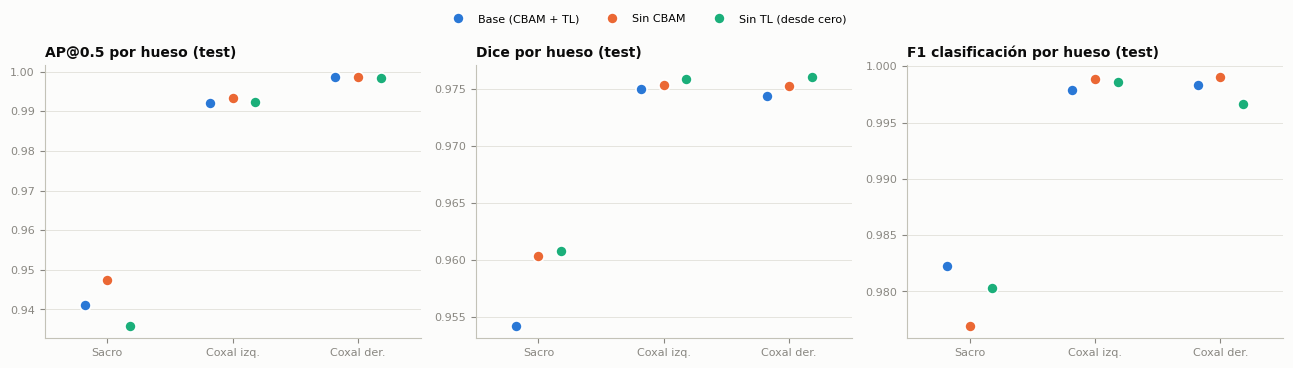

,Base (CBAM + TL),Sin CBAM,Sin TL (desde cero)
AP@0.5 SA,0.941,0.948,0.936
AP@0.5 LI,0.992,0.993,0.992
AP@0.5 RI,0.999,0.999,0.998
Dice SA,0.954,0.960,0.961
Dice LI,0.975,0.975,0.976
Dice RI,0.974,0.975,0.976
F1 SA,0.982,0.977,0.980
F1 LI,0.998,0.999,0.999
F1 RI,0.998,0.999,0.997


In [14]:
por_hueso = pd.DataFrame({RUN[r][2]: {f"{m} {b}": e["metricas"][f"{k}_{b}"]
                                      for m, k in (("AP@0.5", "AP50"), ("Dice", "dice"), ("F1", "cls_f1")) for b in ("SA", "LI", "RI")}
                          for r, e in EV.items()})
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
bones = ["Sacro", "Coxal izq.", "Coxal der."]
for ax, (m, k) in zip(axes, (("AP@0.5", "AP50"), ("Dice", "dice"), ("F1 clasificación", "cls_f1"))):
    for j, (r, e) in enumerate(EV.items()):
        vals = [e["metricas"][f"{k}_{b}"] for b in ("SA", "LI", "RI")]
        ax.plot(np.arange(3) + (j - 1) * 0.18, vals, "o", ms=8, color=RUN[r][0], mec="white", mew=1.2, label=RUN[r][2])
    ax.set_xticks(range(3), bones)
    ax.set_xlim(-0.5, 2.5)
    ax.set_title(f"{m} por hueso (test)", loc="left", fontsize=10)
    ax.grid(axis="x", visible=False)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
savefig(fig, "09_por_hueso_test")
plt.show()
por_hueso.round(3)

El sacro es el hueso que más le cuesta a los tres modelos: es más pequeño y aparece en menos cortes.

## 10. Ablación

Cada variante cambia una sola cosa respecto al modelo base:

- Sin CBAM: se quitan los dos módulos de atención.
- Sin TL: el backbone arranca con pesos aleatorios.

In [15]:
keys = ["mAP@0.50", "mAP@[.50:.95]", "IoU_promedio", "dice_hueso", "dice_SA", "cls_f1_macro", "cls_auc_macro"]
abl = pd.DataFrame({RUN[r][2]: {k: e["metricas"][k] for k in keys} for r, e in EV.items()})
base = abl[RUN["base"][2]]
display(abl.round(4))
display((abl.sub(base, axis=0)).drop(columns=RUN["base"][2]).round(4).rename(columns=lambda c: f"Δ {c} − base"))

h0 = {r: h.head(5)["mAP@[.50:.95]"].round(3).tolist() for r, h in H.items()}
pd.DataFrame(h0, index=[f"época {i}" for i in range(5)]).rename(columns=lambda r: RUN[r][2])

,Base (CBAM + TL),Sin CBAM,Sin TL (desde cero)
mAP@0.50,0.977,0.980,0.976
mAP@[.50:.95],0.841,0.845,0.840
IoU_promedio,0.911,0.912,0.911
dice_hueso,0.968,0.970,0.971
dice_SA,0.954,0.960,0.961
cls_f1_macro,0.993,0.992,0.992
cls_auc_macro,0.999,0.999,0.999


,Δ Sin CBAM − base,Δ Sin TL (desde cero) − base
mAP@0.50,2.600e-03,-1.700e-03
mAP@[.50:.95],4.000e-03,-1.200e-03
IoU_promedio,1.300e-03,2.000e-04
dice_hueso,2.400e-03,3.000e-03
dice_SA,6.100e-03,6.500e-03
cls_f1_macro,-1.200e-03,-1.000e-03
cls_auc_macro,2.000e-04,-1.000e-04


,Base (CBAM + TL),Sin CBAM,Sin TL (desde cero)
época 0,0.664,0.673,0.650
época 1,0.706,0.687,0.672
época 2,0.730,0.733,0.679
época 3,0.738,0.753,0.712
época 4,0.749,0.765,0.725


En test los tres quedan prácticamente iguales: las diferencias son de 0,01 o menos. Con una sola corrida por modelo no se puede decir que uno sea mejor que otro.

Lo que sí se ve es que el transfer learning hace que el modelo aprenda más rápido al principio. Al final, el modelo que arranca desde cero llega al mismo punto.

## 11. Predicciones

Un paciente de test. Arriba está el ground truth y abajo la predicción del modelo base; la caja punteada es la real.

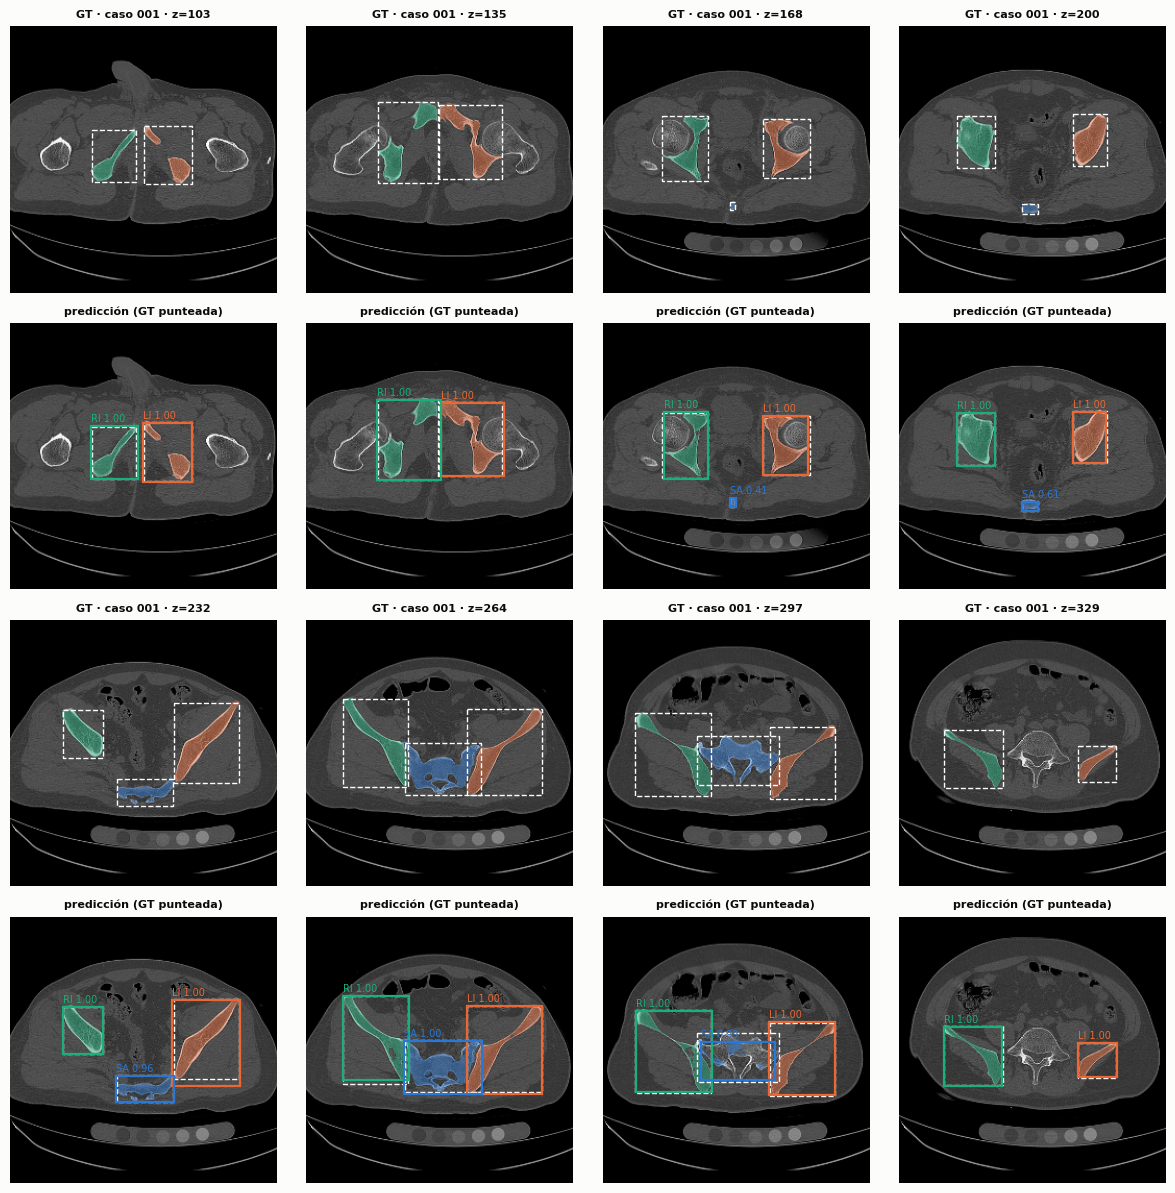

In [16]:
gal_png = FIG / "11_predicciones_test.png"
if HAS_CACHE and HAS_CKPT and HAS_TORCH:
    from pengwin.data.dataset import PengwinSlices, read_split
    from pengwin.data.slice_cache import load_case_cache
    from pengwin.detection.grid import decode
    from pengwin.models.pengwin_net import PengwinNet
    from pengwin.visualization.overlay import prediction_grid

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ck = torch.load(CKPT["base"], map_location="cpu", weights_only=False)
    cfgk = ck["cfg"]
    model = PengwinNet(cfgk["model"]).to(dev).eval()
    model.load_state_dict(ck["model"])
    case = read_split(ROOT / cfgk["data"]["splits"], "test")[0]
    _, _, meta = load_case_cache(CACHE / case)
    bone = meta["bone_slices"]
    zs = [bone[i] for i in np.linspace(0, len(bone) - 1, 10).round().astype(int)[1:-1]]
    ds = PengwinSlices(CACHE, [case], cfgk, train=False, slices=[(case, z) for z in zs])
    batch = next(iter(torch.utils.data.DataLoader(ds, batch_size=len(ds))))
    with torch.no_grad():
        out = model(batch["image"].to(dev))
    pp = cfgk["postprocess"]
    dets = decode(out["det_scores"], out["det_ltrb"], 8, 256, pp["det_score_threshold"], pp["nms_iou"], pp["max_boxes_per_class"])
    sem = out["seg_logits"].argmax(1).cpu().numpy()
    samples = [{"image": batch["image"][i, 1].numpy(), "title": f"caso {case} · z={z}", "gt_semantic": batch["semantic"][i].numpy(),
                "gt_boxes": batch["boxes"][i].numpy(), "gt_present": batch["present"][i].numpy() > 0.5, "pred_semantic": sem[i],
                "pred_boxes": {k: v.cpu().numpy() for k, v in dets[i].items()}} for i, z in enumerate(zs)]
    fig = prediction_grid(samples)
    savefig(fig, "11_predicciones_test")
    plt.show()
else:
    show_saved(gal_png)

## 12. Pendientes

Semana 10:
- Separar los fragmentos (región menos borde, luego componentes conexas en 3D).
- Medir la distancia en mm entre fragmentos.
- Calcular Dice por fragmento.
- Comparar contra SAM.
- Medir la latencia en CPU.

Semana 11:
- Visualizadores 2 y 3 en Streamlit.
- Túnel de Cloudflare.
- Model card y video de respaldo.

Limitaciones que ya conocemos:
- El modelo ve píxeles de unos 1,3 mm, así que los bordes pueden tener ese error.
- Si dos fragmentos que se tocan se fusionan, el pequeño se pierde.
- Falta confirmar con el profesor que se acepta el transfer learning desde el Taller 3.

## 13. Cómo reproducirlo

```powershell
pip install -r requirements.txt; pip install -e .
python -m pytest
python scripts/build_slice_cache.py  --data-dir D:/PENGWIN/01_data --cache-dir D:/PENGWIN/data_processed
python scripts/overfit_batch.py      --cache-dir D:/PENGWIN/data_processed
python scripts/calibrate_lambdas.py  --cache-dir D:/PENGWIN/data_processed
python scripts/train.py              --cache-dir D:/PENGWIN/data_processed --name base
python scripts/evaluate.py           --cache-dir D:/PENGWIN/data_processed --ckpt checkpoints/base/best.pth checkpoints/sin_cbam/best.pth checkpoints/sin_tl/best.pth
python scripts/plot_training_curves.py
```

In [17]:
arch = [("reports/decisiones_de_diseno.md", "Decisiones de diseño y su evidencia (§1-9)"),
        ("reports/lambdas.json", "Calibración de λ"), ("reports/overfit/overfit_base.json", "Prueba de overfit"),
        ("reports/train/<modelo>.json, <modelo>_history.csv", "Mejor época y curvas de cada entrenamiento"),
        ("reports/eval/<modelo>_test.json", "Métricas en test"), ("reports/figures/sustentacion/", "Figuras de este notebook"),
        ("IA_USAGE.md", "Bitácora de uso de IA (entradas 001-004)")]
display(pd.DataFrame(arch, columns=["Archivo", "Contenido"]).style.hide(axis="index"))
print("sha256 de splits.json:", sp["sha256"])

Archivo,Contenido
reports/decisiones_de_diseno.md,Decisiones de diseño y su evidencia (§1-9)
reports/lambdas.json,Calibración de λ
reports/overfit/overfit_base.json,Prueba de overfit
"reports/train/.json, _history.csv",Mejor época y curvas de cada entrenamiento
reports/eval/_test.json,Métricas en test
reports/figures/sustentacion/,Figuras de este notebook
IA_USAGE.md,Bitácora de uso de IA (entradas 001-004)


sha256 de splits.json: e794349f44914b85810f6c49e52b826c49c9a840695972d6f8ea3f530f677705
